In [1]:
using QuantumOptics
import PhysicalConstants.CODATA2018: c_0
using Unitful
using PyPlot
using LinearAlgebra

### Parameters

In [2]:
# Nbr of particles
N = 1

# Normalisation parameters
λ = 421e-9
γ = 32.7e6 # In Hz

# Physical values
ω0 = (2π*ustrip(c_0)/λ)
ωl = ω0
kl = [ustrip(c_0)/ωl, 0, 0] # Laser along x
Ω = 1e7 # Taken from Barbut arXiv:2412.02541v1

# Position of atoms
a = 1e-6 # Distance between atoms
r0 = [[0, 0, 0], [a, 0, 0]]

# Normalization
ω0 = ω0 / γ
ωl = ωl / γ
kl = kl * λ
r0 = r0 / λ
Ω = Ω / γ

# Integration parameter
tstep = 0.1
T = [0:tstep:10;]; # Normalised time

### Parametrisation

In [3]:
# Basis
b1 = SpinBasis(1//2)

# One body operators
σp = sigmap(b1)
σm = sigmam(b1)
nup = σp*σm
ndown = σm*σp

# Many body operators
Jz = -8*ndown -9*nup; # 2 level system but GS has mJ = -8, ES has mJ = -9

### Hamiltonians

In [4]:
HRO = Ω * (exp(1im*r0[1]'kl)*σp + exp(-1im*r0[1]'kl)*σm);

In [5]:
J = [σm];

# Spontaneous emission no $H$

In [16]:
# Initial state
Ψ0_mb = tensor([spinup(b1) for i = 1:N]...)
Γ = Matrix(I, N, N) # Normalized Γ

# Time evolution
ρt_se = timeevolution.master(T, Ψ0_mb, sparse(one(b1)), J; rates=Γ, dt=tstep)[2];

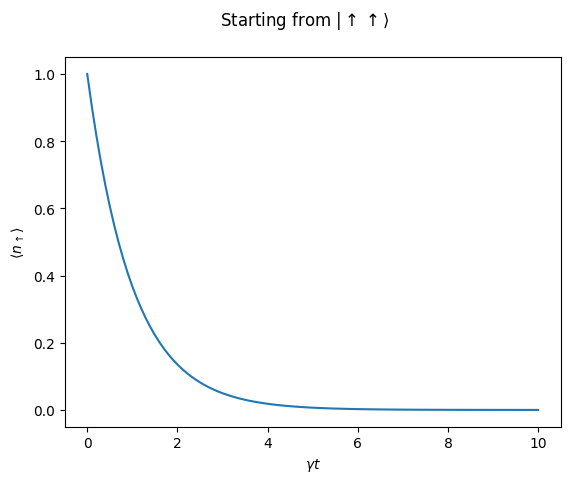

In [17]:
figure()
plot(T, real(expect(nup, ρt_se)))
xlabel(L"$\gamma t$")
ylabel(L"$\langle  n_{\uparrow} \rangle $")
suptitle(L"Starting from $|\uparrow \uparrow \rangle $")
pygui(false); gcf()
#pygui(true); show()

# Without interactions

In [18]:
# Initial state
Ψ0_mb = tensor([spindown(b1) for i = 1:N]...)

# Time evolution
Γ = 1. * Matrix(I, N, N) # Normalized Γ
ρt_indep = timeevolution.master(T, Ψ0_mb, HRO, J; rates=Γ, dt=tstep)[2];

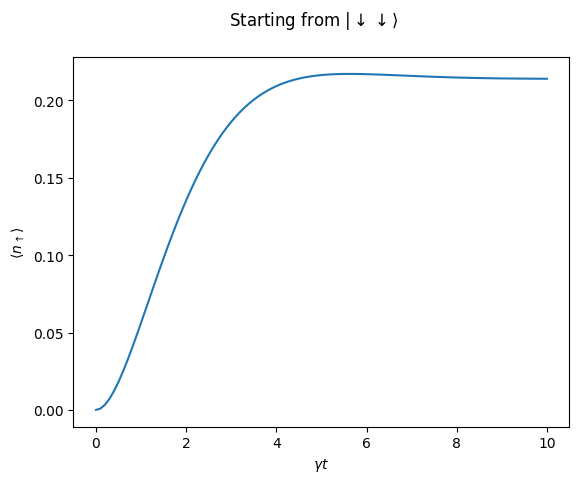

In [19]:
figure()
plot(T, real(expect(nup, ρt_indep)))
xlabel(L"$\gamma t$")
ylabel(L"$\langle  n_{\uparrow} \rangle $")
suptitle(L"Starting from $|\downarrow \downarrow \rangle $")
pygui(false); gcf()
#pygui(true); show()

# Without interactions, varying $\Omega$

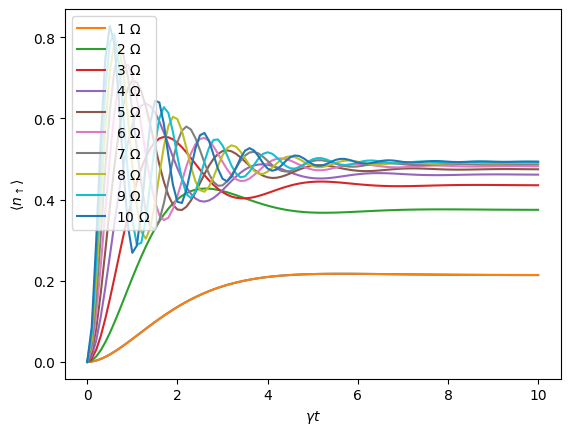

In [25]:
figure()
plot(T, real(expect(nup, ρt_indep)))
for i in range(1, 10)
    HRO_var = i*Ω * (exp(1im*r0[1]'kl)*σp + exp(-1im*r0[1]'kl)*σm)
    ρt_indep_var_Ω = timeevolution.master(T, Ψ0_mb, HRO_var, J; rates=Γ, dt=tstep)[2]
    plot(T, real(expect(nup, ρt_indep_var_Ω)), label=string(i)*L" $\Omega$")
end
legend()
xlabel(L"$\gamma t$")
ylabel(L"$\langle  n_{\uparrow} \rangle $")
pygui(false); gcf()